In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/3
    print("準備完了！このまま下のセルを実行できます。")

# 第3章 基本分布 (Standard Distributions)
## 3.1 離散変数 (Discrete Variables)

本ノートブックは、教科書『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』(Christopher M. Bishop & Hugh Bishop 著, Springer 2024) の **第3章「基本分布 (Standard Distributions)」3.1節「離散変数 (Discrete Variables)」** を理論解説・数式厳密導出・Python実装・図版再現のすべてにおいて完全にカバーするものです。

---

### 第3章 導入: 密度推定 (Density Estimation) の本質と課題

機械学習および深層学習において、有限個の観測データ集合 $\mathcal{D} = \{x_1, \dots, x_N\}$ が与えられたとき、その背後にある未知の確率分布 $p(x)$ をモデル化する問題を **密度推定 (density estimation)** と呼びます。

この問題は根本的に **不良設定問題 (ill-posed problem)** です。なぜなら、有限個のデータ点において非ゼロの値をとる確率分布は無限に存在するため、データのみから唯一の真の分布を一意に決定することは不可能だからです。したがって、どのような関数形や統計的仮定を事前におくかという「**モデル選択 (model selection)**」が極めて重要となります。

- **パラメトリック分布 (Parametric distributions)**:
  少数の調整可能パラメータ（平均や分散など）によって支配される確率分布（本節の離散分布やガウス分布など）。観測データからパラメータを決定する主要な枠組みとして **最尤推定 (Maximum Likelihood Estimation: MLE)** を用います。本章ではデータが **独立同分布 (independent and identically distributed: i.i.d.)** であると仮定します。
- **ノンパラメトリック手法 (Nonparametric methods)**:
  特定の関数形を仮定せず、データのサイズに応じて分布の柔軟性が変化する手法（3.5節のヒストグラム法、K近傍法、カーネル密度推定）。全データを保持する必要があるため大規模データでは計算効率が低下します。
- **深層学習の立ち位置**:
  多数（しかし固定数）のパラメータを持つ多層ニューラルネットワークによって、パラメトリックモデルの高い計算効率と、ノンパラメトリック手法の柔軟な表現力を融合します。

---

### 目次
- [3.1.1 ベルヌーイ分布 (Bernoulli distribution)](#sec_3_1_1)
  - 確率質量関数と指数形式の統一 (式 3.1, 3.2)
  - 期待値と分散の厳密導出 (式 3.3, 3.4)
  - 尤度関数・対数尤度関数と十分統計量 (式 3.5, 3.6)
  - 最尤推定量の微積分導出 (式 3.7, 3.8)
  - 数値検証: 対数尤度の凹性と大数の法則による収束
- [3.1.2 二項分布 (Binomial distribution)](#sec_3_1_2)
  - 確率質量関数と二項係数 (式 3.9, 3.10)
  - **Figure 3.1 の教科書完全再現プロット** (式 3.9, $N=10, \mu=0.25$)
  - 期待値 $E[m] = N\mu$ と分散 $\text{var}[m] = N\mu(1-\mu)$ の2通りの厳密証明 (式 3.11, 3.12)
  - パラメータ感度分析と中心極限定理（正規分布近似）
- [3.1.3 多項分布 (Multinomial distribution)](#sec_3_1_3)
  - 1-of-$K$ 表現（ワンホット表現）と確率制約 (式 3.13, 3.14)
  - 正規化と期待値ベクトル $E[\mathbf{x}] = \boldsymbol{\mu}$ (式 3.15, 3.16)
  - 尤度関数と十分統計量 $\mathbf{m}$ (式 3.17, 3.18, 3.19)
  - **ラグランジュ未定乗数法による最尤推定値 $\mu_k^{\text{ML}} = m_k / N$ の完全導出** (式 3.20, 3.21, 3.22)
  - 多項分布の確率関数と多項係数 (式 3.23, 3.24)
  - 数値検証: 偏ったサイコロ実験と3クラス・シンプレックス可視化
- [まとめと3.2節「多変量ガウス分布」への展望](#sec_summary)


In [1]:
# 環境設定と共通モジュールのインポート
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# プロジェクトルートの common モジュールをインポート
sys.path.append(os.path.abspath('..'))
from common.plot_utils import setup_style, save_plot
from common.probability import (
    BernoulliDistribution,
    BinomialDistribution,
    MultinomialDistribution,
    plot_figure_3_1
)

setup_style()
print("Libraries and common modules loaded successfully.")


Libraries and common modules loaded successfully.


<a id="sec_3_1_1"></a>
### 3.1.1 ベルヌーイ分布 (Bernoulli distribution)

コイン投げのように、結果が2つの値のうちいずれか一方のみをとる単一の2値確率変数 $x \in \{0, 1\}$ を考えます。
ここで $x = 1$ を「表 (heads)」、$x = 0$ を「裏 (tails)」と定義します。

コインが歪んでいる場合（Figure 2.2 参照）、表が出る確率と裏が出る確率は等しいとは限りません。
表が出る確率をパラメータ $\mu$ ($0 \leqslant \mu \leqslant 1$) で表すと、
$$p(x = 1 | \mu) = \mu \tag{3.1}$$
であり、確率の全和が 1 であることから、裏が出る確率は $p(x = 0 | \mu) = 1 - \mu$ と定まります。

#### 確率質量関数 (式 3.2) の統一形式
この2つのケースを1本の数式としてエレガントにまとめたものが **ベルヌーイ分布 (Bernoulli distribution)** です：

$$\text{Bern}(x | \mu) = \mu^x (1 - \mu)^{1 - x} \tag{3.2}$$

> **数式変形のポイント**:
> - $x = 1$ のとき: $\mu^1 (1 - \mu)^{1 - 1} = \mu \cdot (1 - \mu)^0 = \mu$
> - $x = 0$ のとき: $\mu^0 (1 - \mu)^{1 - 0} = 1 \cdot (1 - \mu)^1 = 1 - \mu$
> 
> このように、$x$ と $1-x$ を指数に配置することで、条件分岐を使わずに解析的な微分や積の計算が容易な代数形式に統一されています。

---

#### 期待値と分散の厳密導出 (式 3.3, 式 3.4)

離散確率変数の定義に従い、期待値 $\mathbb{E}[x]$ および分散 $\text{var}[x]$ を導出します。

1. **正規化の確認**:
   $$\sum_{x \in \{0, 1\}} p(x|\mu) = (1 - \mu) + \mu = 1$$

2. **期待値 $\mathbb{E}[x]$ の導出 (式 3.3)**:
   $$\mathbb{E}[x] = \sum_{x \in \{0, 1\}} x \cdot p(x|\mu) = 0 \cdot (1 - \mu) + 1 \cdot \mu = \mu \tag{3.3}$$

3. **分散 $\text{var}[x]$ の導出 (式 3.4)**:
   分散の定義 $\text{var}[x] = \mathbb{E}[(x - \mathbb{E}[x])^2] = \mathbb{E}[x^2] - (\mathbb{E}[x])^2$ を用います。
   $x \in \{0, 1\}$ であるため、$x^2$ は常に $x$ と等しくなります（$0^2 = 0, 1^2 = 1$）。
   したがって、2次モーメントは期待値と一致します：
   $$\mathbb{E}[x^2] = \sum_{x \in \{0, 1\}} x^2 p(x|\mu) = 0^2 \cdot (1 - \mu) + 1^2 \cdot \mu = \mu$$
   これより、分散は次のように求まります：
   $$\text{var}[x] = \mathbb{E}[x^2] - (\mathbb{E}[x])^2 = \mu - \mu^2 = \mu (1 - \mu) \tag{3.4}$$

---

#### 尤度関数と対数尤度関数 (式 3.5, 式 3.6)

いま、独立同分布 (i.i.d.) の仮定の下で得られた $N$ 個の観測データ集合 $\mathcal{D} = \{x_1, \dots, x_N\}$ を考えます。
乗法定理（独立性）により、データ全体の同時確率である **尤度関数 (likelihood function)** は各点の確率の総乗になります：

$$p(\mathcal{D} | \mu) = \prod_{n=1}^N p(x_n | \mu) = \prod_{n=1}^N \mu^{x_n} (1 - \mu)^{1 - x_n} \tag{3.5}$$

尤度関数を直接最大化する代わりに、単調増加関数である自然対数をとった **対数尤度関数 (log-likelihood function)** を最大化します。対数をとることで、積が和に変換され微分の計算が大幅に平易になり、浮動小数点数のアンダーフローを防ぐことができます：

$$\ln p(\mathcal{D} | \mu) = \sum_{n=1}^N \ln p(x_n | \mu) = \sum_{n=1}^N \{ x_n \ln \mu + (1 - x_n) \ln(1 - \mu) \} \tag{3.6}$$

ここで注目すべきは、対数尤度関数がデータ点 $x_n$ の個々の値そのものではなく、その総和 $\sum_{n=1}^N x_n$ のみに依存している点です。
この総和は、本分布に対するデータの **十分統計量 (sufficient statistic)** の代表例です。

---

#### 最尤推定量 (MLE) の微積分導出 (式 3.7, 式 3.8)

対数尤度関数 (3.6) をパラメータ $\mu$ に関して微分し、0 とおくことで最尤推定量を求めます。

$$\frac{d}{d\mu} \ln p(\mathcal{D} | \mu) = \sum_{n=1}^N \left( \frac{x_n}{\mu} - \frac{1 - x_n}{1 - \mu} \right) = 0$$

総和を展開してまとめます：
$$\frac{1}{\mu} \sum_{n=1}^N x_n - \frac{1}{1 - \mu} \sum_{n=1}^N (1 - x_n) = 0$$
$$\frac{1}{\mu} \sum_{n=1}^N x_n - \frac{1}{1 - \mu} \left( N - \sum_{n=1}^N x_n \right) = 0$$

両辺に $\mu (1 - \mu)$ を掛けます：
$$(1 - \mu) \sum_{n=1}^N x_n - \mu \left( N - \sum_{n=1}^N x_n \right) = 0$$
$$\sum_{n=1}^N x_n - \mu \sum_{n=1}^N x_n - N\mu + \mu \sum_{n=1}^N x_n = 0$$
$$\sum_{n=1}^N x_n - N\mu = 0$$

したがって、最尤推定量 $\mu_{\text{ML}}$ は以下のように求まります：

$$\mu_{\text{ML}} = \frac{1}{N} \sum_{n=1}^N x_n \tag{3.7}$$

これは **標本平均 (sample mean)** として広く知られている量です。
データセット中の表 ($x = 1$) の観測回数を $m = \sum_{n=1}^N x_n$ と定義すると、式 (3.7) は次の簡潔な形になります：

$$\mu_{\text{ML}} = \frac{m}{N} \tag{3.8}$$

すなわち、最尤推定の枠組みでは、表が出る確率は「データセット中に表が出現した割合」に等しくなります。


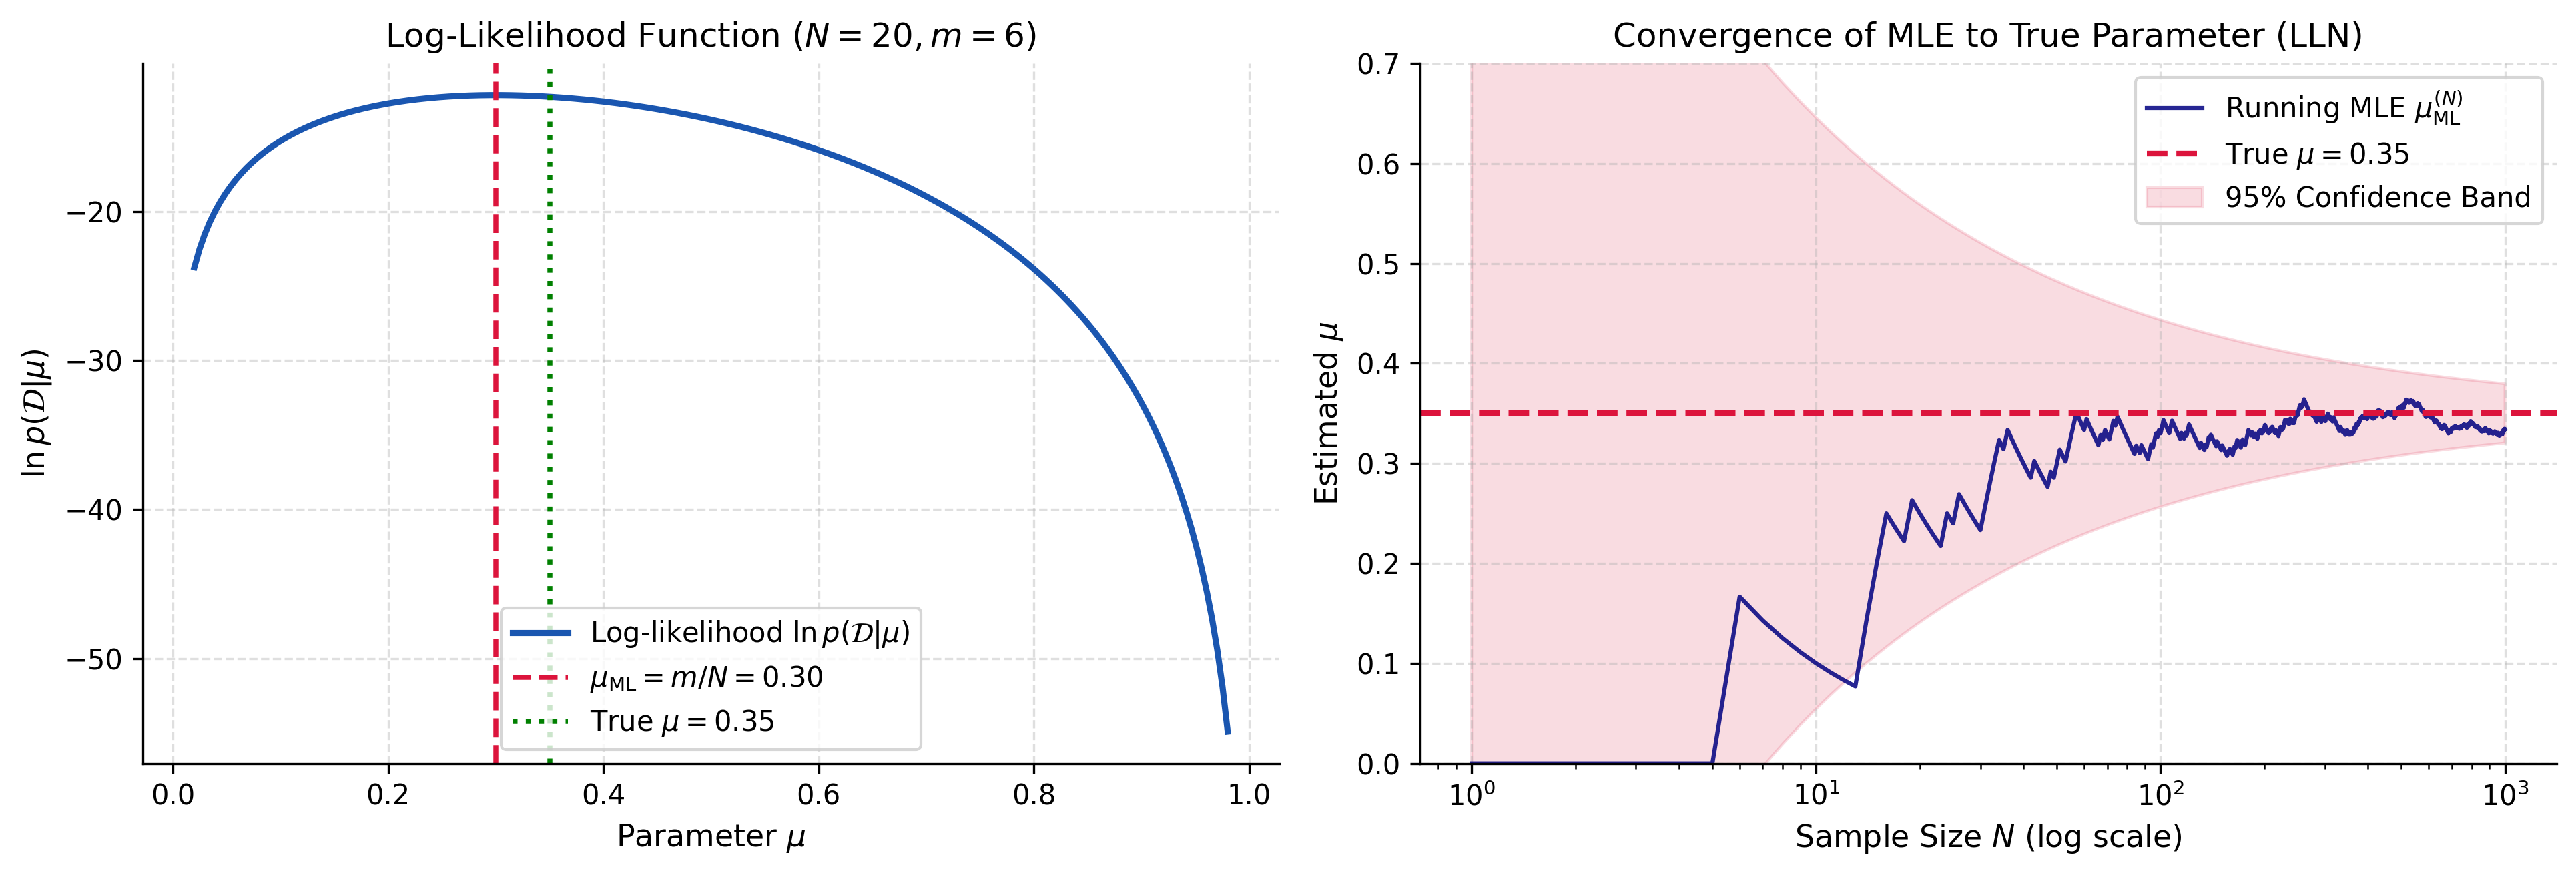

Sample Size N=20: Observed heads m=6, MLE mu_ML=0.3000, True mu=0.35
Sample Size N=1000: Final MLE mu_ML=0.3340, True mu=0.35


In [2]:
# 3.1.1 ベルヌーイ分布の対数尤度曲線と大数の法則シミュレーション
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=300)

# (1) 対数尤度関数の凹性と MLE の位置
true_mu = 0.35
N_sample = 20
np.random.seed(42)
synthetic_data = np.random.binomial(n=1, p=true_mu, size=N_sample)
m_obs = int(np.sum(synthetic_data))
mu_ml_calc = m_obs / N_sample

mu_grid = np.linspace(0.02, 0.98, 200)
log_liks = [BernoulliDistribution.log_likelihood(synthetic_data, mu) for mu in mu_grid]

ax1.plot(mu_grid, log_liks, color='#1A56B0', lw=2.2, label=r'Log-likelihood $\ln p(\mathcal{D}|\mu)$')
ax1.axvline(mu_ml_calc, color='crimson', linestyle='--', lw=1.8, label=f'$\mu_{{\mathrm{{ML}}}} = m/N = {mu_ml_calc:.2f}$')
ax1.axvline(true_mu, color='green', linestyle=':', lw=1.8, label=f'True $\mu = {true_mu:.2f}$')
ax1.set_xlabel(r'Parameter $\mu$', fontsize=11)
ax1.set_ylabel(r'$\ln p(\mathcal{D}|\mu)$', fontsize=11)
ax1.set_title(f'Log-Likelihood Function ($N={N_sample}, m={m_obs}$)', fontsize=12)
ax1.legend(frameon=True, fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.4)

# (2) 大数の法則: N の増大に伴う mu_ML の真値への収束
N_max = 1000
large_data = np.random.binomial(n=1, p=true_mu, size=N_max)
running_m = np.cumsum(large_data)
running_n = np.arange(1, N_max + 1)
running_mle = running_m / running_n

ax2.plot(running_n, running_mle, color='navy', lw=1.5, alpha=0.85, label=r'Running MLE $\mu_{\mathrm{ML}}^{(N)}$')
ax2.axhline(true_mu, color='crimson', linestyle='--', lw=2.0, label=f'True $\mu = {true_mu}$')
ax2.fill_between(
    running_n,
    true_mu - 1.96 * np.sqrt(true_mu * (1 - true_mu) / running_n),
    true_mu + 1.96 * np.sqrt(true_mu * (1 - true_mu) / running_n),
    color='crimson', alpha=0.15, label='95% Confidence Band'
)
ax2.set_xscale('log')
ax2.set_xlabel(r'Sample Size $N$ (log scale)', fontsize=11)
ax2.set_ylabel(r'Estimated $\mu$', fontsize=11)
ax2.set_ylim(0.0, 0.7)
ax2.set_title('Convergence of MLE to True Parameter (LLN)', fontsize=12)
ax2.legend(frameon=True, fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Sample Size N={N_sample}: Observed heads m={m_obs}, MLE mu_ML={mu_ml_calc:.4f}, True mu={true_mu}")
print(f"Sample Size N={N_max}: Final MLE mu_ML={running_mle[-1]:.4f}, True mu={true_mu}")


<a id="sec_3_1_2"></a>
### 3.1.2 二項分布 (Binomial distribution)

前項では単一の試行 $x$ およびその独立な観測系列を扱いましたが、サイズ $N$ のデータセットにおいて **表 ($x=1$) が観測された総回数 $m$ そのものが従う確率分布** を求めることができます。これが **二項分布 (binomial distribution)** です。

式 (3.5) より、表が $m$ 回、裏が $N - m$ 回出る特定の系列（例えば、最初の $m$ 回がすべて表で、残り $N-m$ 回が裏となる順序）が得られる確率は、積の法則より次式に比例します：
$$\mu^m (1 - \mu)^{N - m}$$

しかし、合計 $m$ 回の表が得られる試行の順序は多数存在します。正規化係数を得るためには、$N$ 回のコイン投げの中で表が出る $m$ 回の組み合わせの総数をすべて足し合わせる必要があります。
非復元抽出で $N$ 個の同一の対象から $m$ 個を選ぶ組み合わせの総数は **二項係数 (binomial coefficient)** で与えられます：

$$\binom{N}{m} \equiv \frac{N!}{(N - m)! m!} \tag{3.10}$$

したがって、二項分布の確率質量関数は次式で定義されます：

$$\text{Bin}(m | N, \mu) = \binom{N}{m} \mu^m (1 - \mu)^{N - m} \tag{3.9}$$

---

#### 二項定理による正規化の証明

全事象確率の和が 1 になることは、高校数学でも馴染み深い **二項定理 (binomial theorem)** から直ちに証明されます：
$$\sum_{m=0}^N \text{Bin}(m | N, \mu) = \sum_{m=0}^N \binom{N}{m} \mu^m (1 - \mu)^{N - m} = \{\mu + (1 - \mu)\}^N = 1^N = 1$$

---

#### 期待値と分散の厳密導出 (式 3.11, 式 3.12)

二項分布の平均 $\mathbb{E}[m]$ と分散 $\text{var}[m]$ は、以下の2つの独立したアプローチで導出することができます。

##### 導出法 1: 独立な確率変数の和（統計的アプローチ）
二項変数は、各試行における独立なベルヌーイ変数の和として表すことができます：
$$m = x_1 + x_2 + \dots + x_N, \quad x_n \stackrel{\text{i.i.d.}}{\sim} \text{Bern}(\mu)$$

独立な事象に対しては「和の平均は平均の和」であり、「和の分散は分散の和」となる性質（加法性）が成り立ちます。
各観測の平均と分散は式 (3.3) および (3.4) より $\mathbb{E}[x_n] = \mu$, $\text{var}[x_n] = \mu(1-\mu)$ であるため、
$$\mathbb{E}[m] \equiv \sum_{m=0}^N m \text{Bin}(m | N, \mu) = \sum_{n=1}^N \mathbb{E}[x_n] = N \mu \tag{3.11}$$
$$\text{var}[m] \equiv \sum_{m=0}^N (m - \mathbb{E}[m])^2 \text{Bin}(m | N, \mu) = \sum_{n=1}^N \text{var}[x_n] = N \mu (1 - \mu) \tag{3.12}$$

##### 導出法 2: 二項定理と微分法（微積分アプローチ）
任意の $\mu$ に対して常に成立する二項展開の恒等式を考えます：
$$f(\mu) = \sum_{m=0}^N \binom{N}{m} \mu^m (1 - \mu)^{N - m} = 1$$
この両辺を $\mu$ で微分します：
$$\frac{d}{d\mu} f(\mu) = \sum_{m=0}^N \binom{N}{m} \left\{ m \mu^{m-1} (1 - \mu)^{N - m} - (N - m) \mu^m (1 - \mu)^{N - m - 1} \right\} = 0$$
両辺に $\mu(1-\mu)$ を掛けると：
$$\sum_{m=0}^N \binom{N}{m} \mu^m (1 - \mu)^{N - m} \{ m(1 - \mu) - (N - m)\mu \} = 0$$
ブラケット内を整理すると $m - m\mu - N\mu + m\mu = m - N\mu$ となるため、
$$\sum_{m=0}^N (m - N\mu) \text{Bin}(m | N, \mu) = 0 \implies \sum_{m=0}^N m \text{Bin}(m | N, \mu) = N\mu \sum_{m=0}^N \text{Bin}(m | N, \mu) = N\mu$$
これにより、微積分からも $\mathbb{E}[m] = N\mu$ が厳密に示されます。同様に2階微分を計算することで分散の式 (3.12) も導かれます。


#### Figure 3.1 の忠実再現 (Textbook Figure 3.1 Reproduction)

教科書第68ページの記述に従い、$N = 10$ および $\mu = 0.25$ のときの二項分布 (3.9) のヒストグラムプロットを再現します。

- 試行回数 $N = 10$
- 成功確率 $\mu = 0.25$
- 各 $m \in \{0, 1, \dots, 10\}$ における正確な確率値:
  - $m = 0$: $\binom{10}{0} 0.25^0 0.75^{10} = 0.75^{10} \approx 0.0563$
  - $m = 1$: $\binom{10}{1} 0.25^1 0.75^9 = 10 \cdot 0.25 \cdot 0.75^9 \approx 0.1877$
  - $m = 2$: $\binom{10}{2} 0.25^2 0.75^8 = 45 \cdot 0.0625 \cdot 0.1001 \approx 0.2816$ （最頻値 / Peak）
  - $m = 3$: $\binom{10}{3} 0.25^3 0.75^7 = 120 \cdot 0.0156 \cdot 0.1335 \approx 0.2503$
  - $m = 4$: $\approx 0.1460$
  - $m = 5$: $\approx 0.0584$
  - $m \geqslant 6$: 急速に 0 に減衰


Figure 3.1 saved successfully to: result/fig3_01_binomial_distribution.png
Figure 3.1 saved successfully to: ../result/fig3_01_binomial_distribution.png


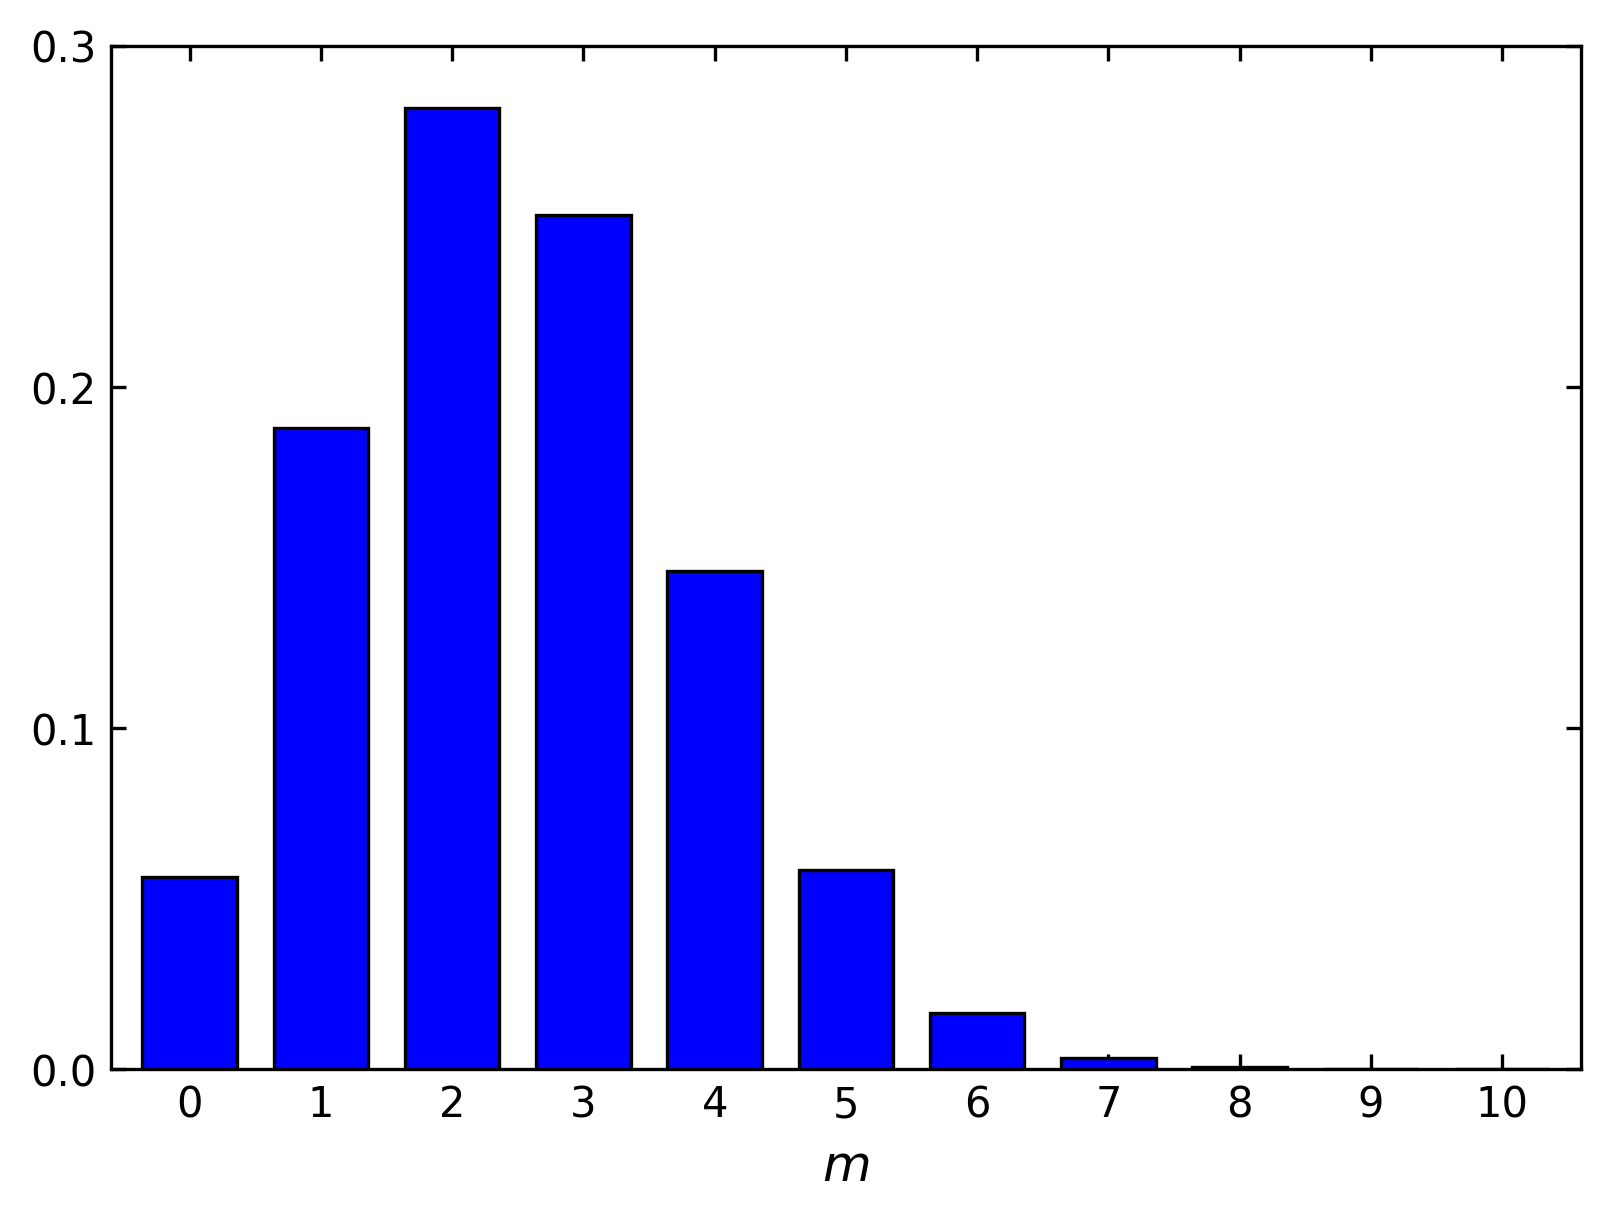

In [3]:
# Figure 3.1: Histogram plot of the binomial distribution for N = 10 and mu = 0.25
fig, ax = plt.subplots(figsize=(5.5, 4.2), dpi=300)

plot_figure_3_1(
    N=10,
    mu=0.25,
    save_paths=[
        "result/fig3_01_binomial_distribution.png",
        "../result/fig3_01_binomial_distribution.png"
    ],
    ax=ax,
    show=False
)

plt.show()


#### 実験結果の分析・考察: Figure 3.1

1. **分布の最頻値 (Mode)**:
   平均値は $\mathbb{E}[m] = N\mu = 10 \times 0.25 = 2.5$ です。離散分布であるため確率が最大となる整数値（最頻値）は $m = 2$ となり、約 $0.2816$ の確率を占めます。
2. **非対称性と歪度 (Skewness)**:
   $\mu = 0.25 < 0.5$ であるため、分布は左側に偏り、右側（大きな $m$ の方向）に長い裾を持つ正の歪度（歪度 $\gamma_1 = \frac{1 - 2\mu}{\sqrt{N\mu(1-\mu)}} = \frac{0.5}{\sqrt{1.875}} \approx +0.365$）を示しています。
3. **中心極限定理への接続**:
   $N$ がさらに大きくなると（例: $N \geqslant 30$）、歪度は減衰し、平均 $N\mu$、分散 $N\mu(1-\mu)$ のガウス分布（正規分布）へと極めて速やかに漸近します（3.2節で詳述）。


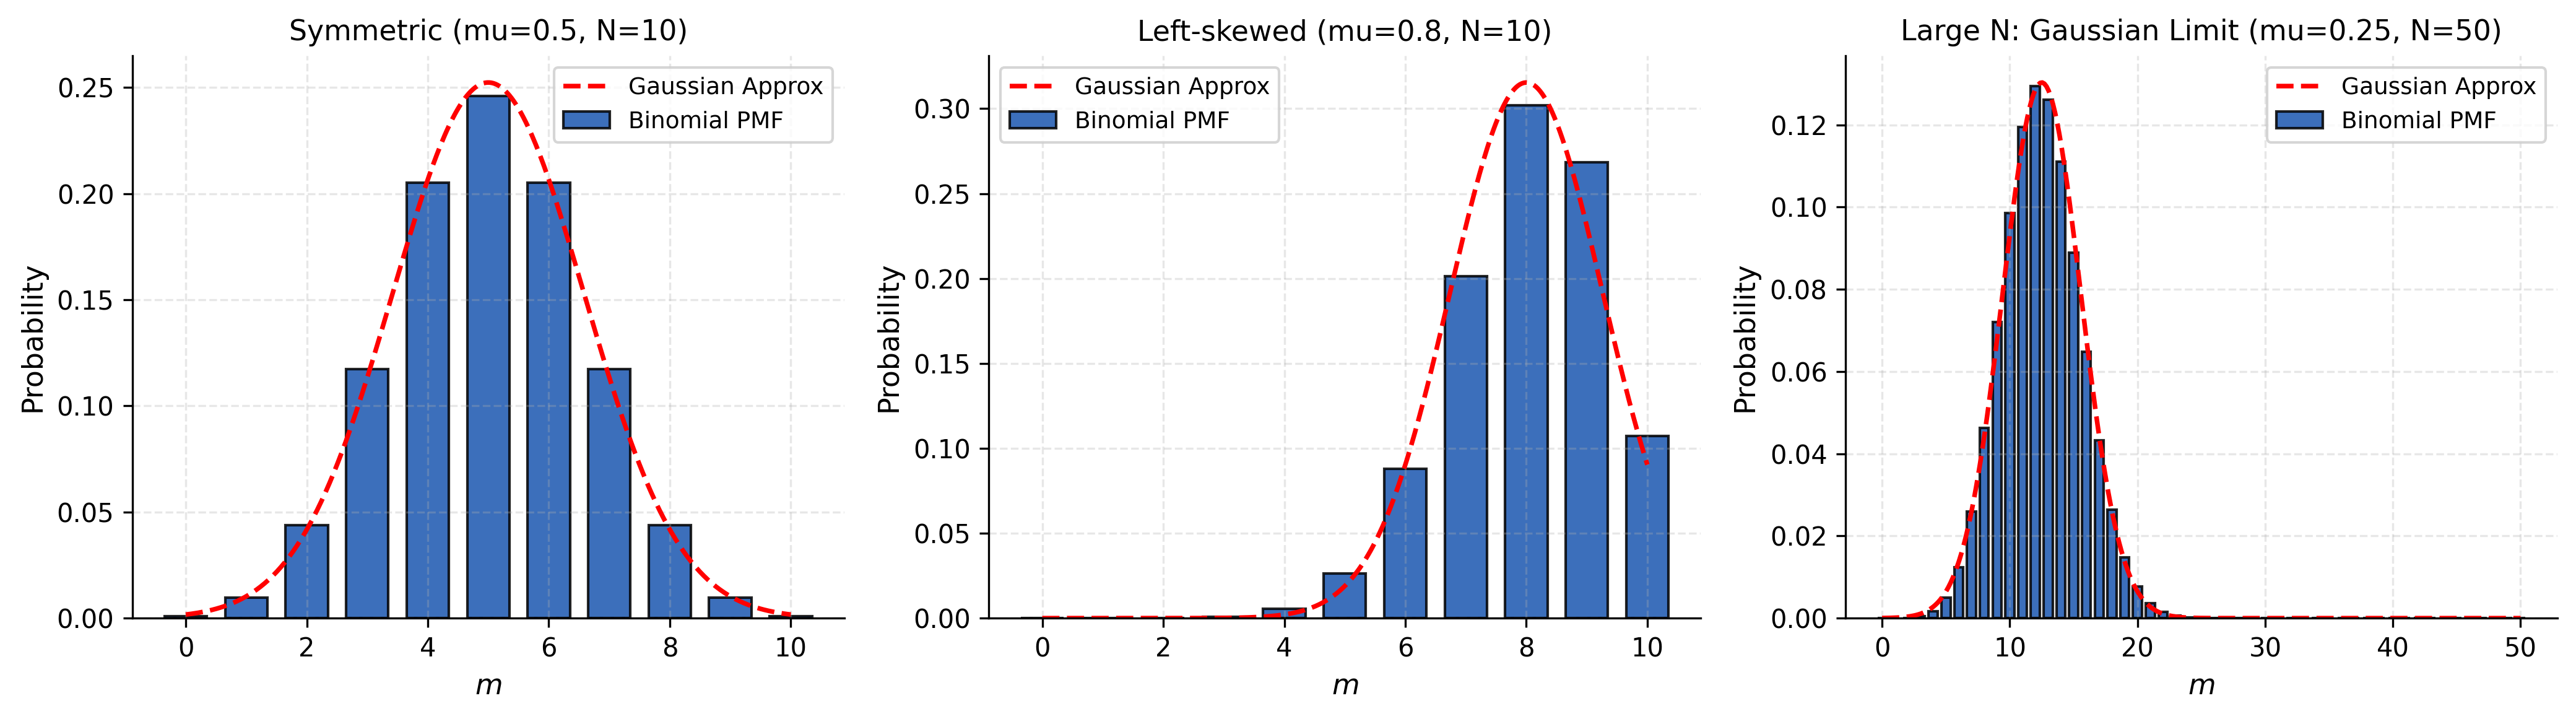

In [4]:
# 二項分布のパラメータ比較と中心極限定理（正規分布近似）の検証
fig, axes = plt.subplots(1, 3, figsize=(14, 4.0), dpi=300)

params = [
    (10, 0.5, "Symmetric (mu=0.5, N=10)"),
    (10, 0.8, "Left-skewed (mu=0.8, N=10)"),
    (50, 0.25, "Large N: Gaussian Limit (mu=0.25, N=50)")
]

for ax, (N_val, mu_val, title) in zip(axes, params):
    binom = BinomialDistribution(N=N_val, mu=mu_val)
    m_vals, probs = binom.pmf_all()
    
    # 二項分布の棒グラフ
    ax.bar(m_vals, probs, width=0.7, color='#1A56B0', edgecolor='black', alpha=0.85, label='Binomial PMF')
    
    # ガウス分布近似曲線を重畳: N(x | N*mu, N*mu*(1-mu))
    mean_val = binom.mean
    std_val = np.sqrt(binom.variance)
    x_cont = np.linspace(0, N_val, 300)
    gauss_pdf = (1.0 / (np.sqrt(2 * np.pi) * std_val)) * np.exp(-0.5 * ((x_cont - mean_val) / std_val) ** 2)
    ax.plot(x_cont, gauss_pdf, 'r--', lw=1.8, label='Gaussian Approx')
    
    ax.set_xlabel(r'$m$', fontsize=11)
    ax.set_ylabel(r'Probability', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(frameon=True, fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


<a id="sec_3_1_3"></a>
### 3.1.3 多項分布 (Multinomial distribution)

2値変数は2つの可能な値のいずれかをとる量を記述するのに適していました。
しかし、現実の多くの問題では、$K$ 個の相互排他的な状態（mutually exclusive states）のいずれかをとる離散変数を扱います（例: サイコロの出目、品詞分類、多クラス画像分類のラベル）。

このような変数を表現する際、特に便利で深層学習でも標準的に用いられるのが **1-of-$K$ 表現（one-hot encoding）** です。
これは、$K$ 次元のベクトル $\mathbf{x}$ であって、ある1つの要素 $x_k$ のみが 1 であり、残りのすべての要素が 0 となるスキームです。

例えば、$K = 6$ の状態で第3の状態（$x_3 = 1$）が生起した観測は次のように表されます：
$$\mathbf{x} = (0, 0, 1, 0, 0, 0)^{\mathrm{T}} \tag{3.13}$$

このベクトルは必然的に拘束条件 $\sum_{k=1}^K x_k = 1$ を満たします。
状態 $k$ が生起する確率（$x_k = 1$ となる確率）をパラメータ $\mu_k$ で表すと、$\mathbf{x}$ の確率分布（カテゴリカル分布）は次式で与えられます：

$$p(\mathbf{x} | \boldsymbol{\mu}) = \prod_{k=1}^K \mu_k^{x_k} \tag{3.14}$$

ここで $\boldsymbol{\mu} = (\mu_1, \dots, \mu_K)^{\mathrm{T}}$ であり、各パラメータは確率としての妥当性から次の制約を満たします：
$$\mu_k \geqslant 0, \quad \sum_{k=1}^K \mu_k = 1$$

分布 (3.14) は、ベルヌーイ分布 (3.2) を3つ以上の状態に一般化したものとみなせます。

---

#### 正規化と期待値 (式 3.15, 式 3.16)

1-of-$K$ 表現の全可能事象は、各基本ベクトル $\mathbf{e}_k$ ($k=1, \dots, K$) の計 $K$ 通りです。

1. **正規化の確認 (式 3.15)**:
   $$\sum_{\mathbf{x}} p(\mathbf{x} | \boldsymbol{\mu}) = \sum_{k=1}^K \mu_k = 1 \tag{3.15}$$

2. **期待値ベクトルの導出 (式 3.16)**:
   $$\mathbb{E}[\mathbf{x} | \boldsymbol{\mu}] = \sum_{\mathbf{x}} p(\mathbf{x} | \boldsymbol{\mu}) \mathbf{x} = \sum_{k=1}^K \mu_k \mathbf{e}_k = (\mu_1, \mu_2, \dots, \mu_K)^{\mathrm{T}} = \boldsymbol{\mu} \tag{3.16}$$

---

#### 尤度関数と十分統計量 (式 3.17, 式 3.18, 式 3.19)

独立な $N$ 個の観測データ集合 $\mathcal{D} = \{\mathbf{x}_1, \dots, \mathbf{x}_N\}$ を考えます。
尤度関数は各観測の確率の総乗になります：

$$p(\mathcal{D} | \boldsymbol{\mu}) = \prod_{n=1}^N \prod_{k=1}^K \mu_k^{x_{nk}} = \prod_{k=1}^K \mu_k^{\sum_{n=1}^N x_{nk}} = \prod_{k=1}^K \mu_k^{m_k} \tag{3.17}$$

ここで、
$$m_k \equiv \sum_{n=1}^N x_{nk} \tag{3.18}$$
は、データセット中で $x_k = 1$ が観測された回数を表します。
尤度関数は $N$ 個のデータ点に対して、これら $K$ 個の量 $m_1, \dots, m_K$ のみを通じて依存しています。
したがって、$m_k$ は本分布に対する **十分統計量 (sufficient statistics)** となります。
なお、各データ点について $\sum_{k=1}^K x_{nk} = 1$ が成り立つため、$m_k$ には次の総和の制約が存在します：
$$\sum_{k=1}^K m_k = N \tag{3.19}$$

---

#### ラグランジュ未定乗数法による最尤推定値の完全導出 (式 3.20, 式 3.21, 式 3.22)

パラメータ $\boldsymbol{\mu}$ の最尤推定量 $\boldsymbol{\mu}^{\text{ML}}$ を求めるためには、等式拘束条件 $\sum_{k=1}^K \mu_k = 1$ の下で、対数尤度関数 $\ln p(\mathcal{D} | \boldsymbol{\mu}) = \sum_{k=1}^K m_k \ln \mu_k$ を最大化する必要があります。

このような等式制約付き最適化問題は、**ラグランジュ未定乗数法 (Lagrange multipliers)** を用いて解きます。
ラグランジュ乗数を $\lambda$ とし、ラグランジュ関数 $L(\boldsymbol{\mu}, \lambda)$ を次のように定義します：

$$L(\boldsymbol{\mu}, \lambda) = \sum_{k=1}^K m_k \ln \mu_k + \lambda \left( \sum_{k=1}^K \mu_k - 1 \right) \tag{3.20}$$

##### ステップ 1: 各パラメータ $\mu_k$ による偏微分
$L$ を任意の $\mu_k$ で偏微分し、0 とおきます：
$$\frac{\partial L}{\partial \mu_k} = \frac{m_k}{\mu_k} + \lambda = 0$$
これより、各 $\mu_k$ は未定乗数 $\lambda$ を用いて次のように表されます：
$$\mu_k = -\frac{m_k}{\lambda} \tag{3.21}$$

##### ステップ 2: 拘束条件によるラグランジュ乗数 $\lambda$ の決定
式 (3.21) を拘束条件 $\sum_{k=1}^K \mu_k = 1$ に代入します：
$$\sum_{k=1}^K \left( -\frac{m_k}{\lambda} \right) = 1 \implies -\frac{1}{\lambda} \sum_{k=1}^K m_k = 1$$
ここで式 (3.19) より $\sum_{k=1}^K m_k = N$ であるため、
$$-\frac{N}{\lambda} = 1 \implies \lambda = -N$$

##### ステップ 3: 最尤推定解の導出
得られた $\lambda = -N$ を式 (3.21) に代入すると、最尤推定量の解が得られます：

$$\mu_k^{\text{ML}} = \frac{m_k}{N} \tag{3.22}$$

これは、$N$ 回の観測のうち状態 $k$ が発生した割合（相対度数）に完全に一致します。

---

#### 多項分布の定義と多項係数 (式 3.23, 式 3.24)

観測総数 $N$ とパラメータ $\boldsymbol{\mu}$ を所与としたとき、各状態の生起回数 $m_1, \dots, m_K$ そのものの同時確率分布を考えることができます。これを **多項分布 (multinomial distribution)** と呼びます。

式 (3.17) から、各生起回数の組 $(m_1, \dots, m_K)$ が得られる確率は $\prod_{k=1}^K \mu_k^{m_k}$ に比例します。
正規化係数は、$N$ 個の要素をサイズ $m_1, m_2, \dots, m_K$ の $K$ 個のグループに分割する組み合わせの総数（多項係数）で与えられます：

$$\text{Mult}(m_1, m_2, \dots, m_K | \boldsymbol{\mu}, N) = \binom{N}{m_1 m_2 \dots m_K} \prod_{k=1}^K \mu_k^{m_k} \tag{3.23}$$

ここで多項係数は階乗を用いて次のように定義されます：

$$\binom{N}{m_1 m_2 \dots m_K} \equiv \frac{N!}{m_1! m_2! \dots m_K!} \tag{3.24}$$

> **二項分布との関係**:
> $K = 2$ の場合、$m_1 = m, m_2 = N - m$, $\mu_1 = \mu, \mu_2 = 1 - \mu$ と置くことで、
> $$\frac{N!}{m! (N - m)!} \mu^m (1 - \mu)^{N - m}$$
> となり、二項分布の式 (3.9) に完全に一致します。


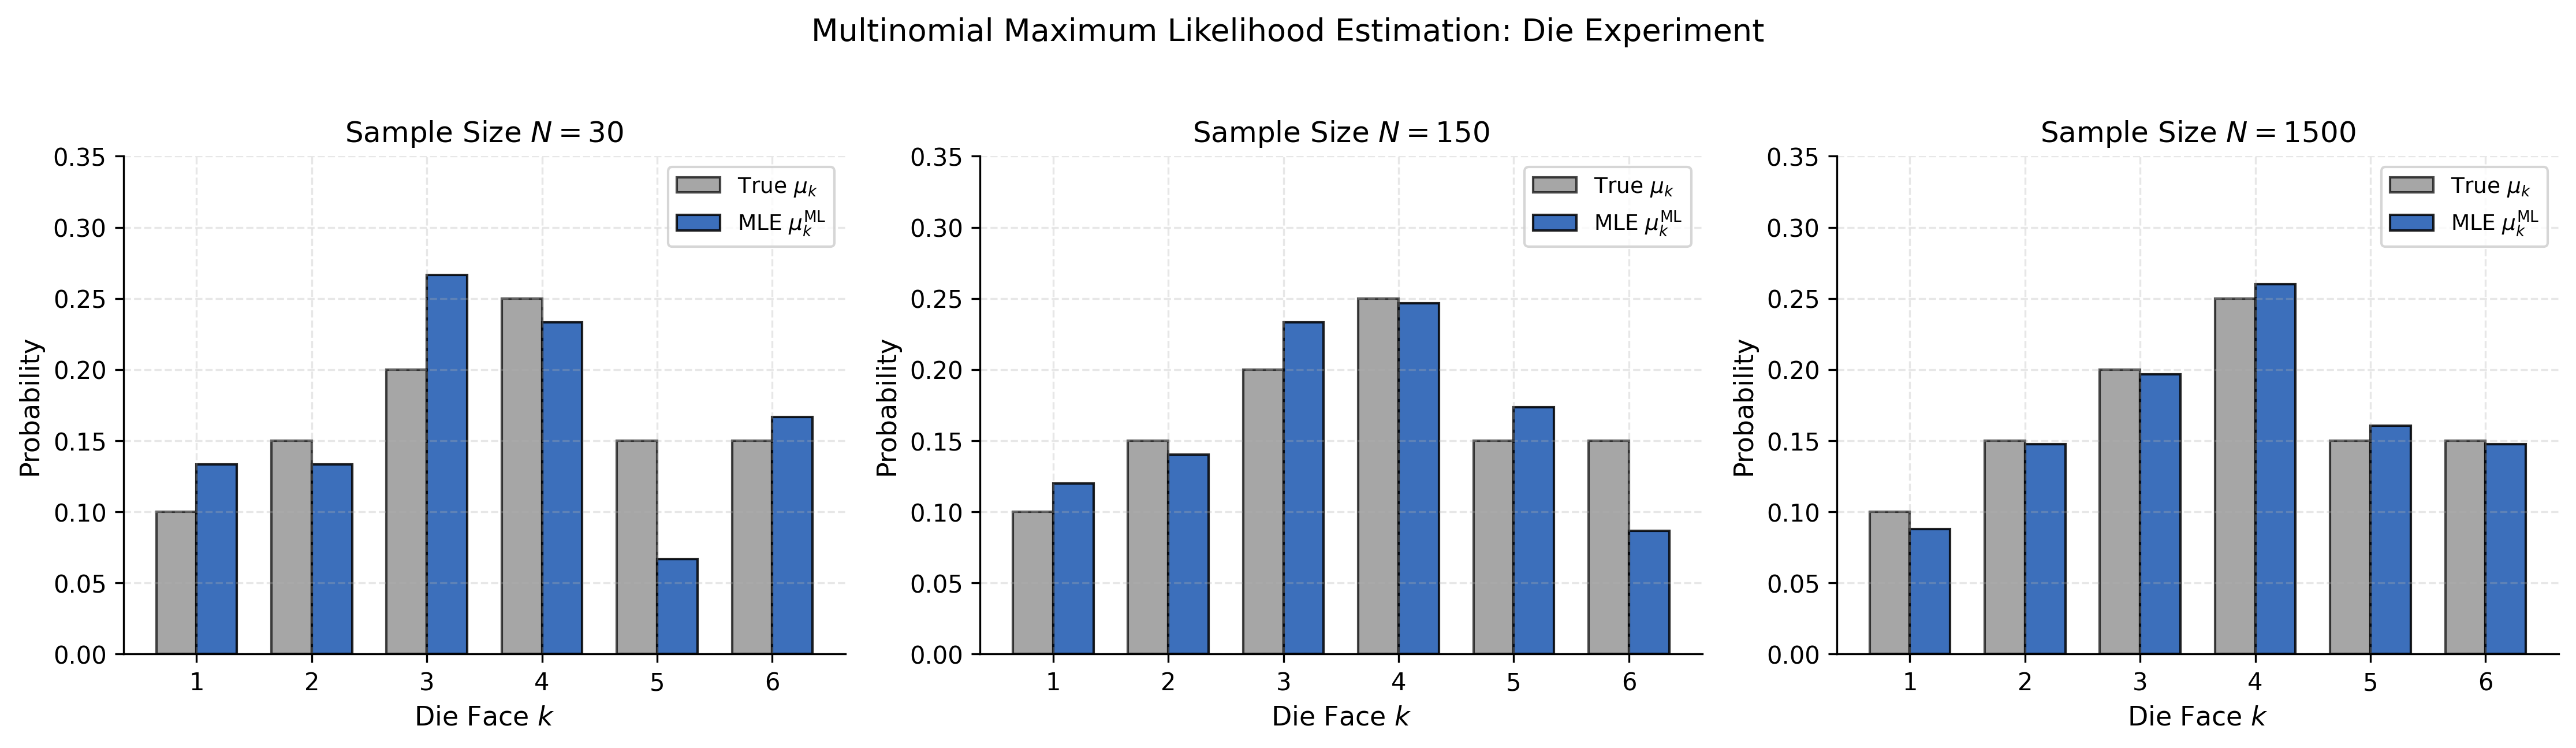

True probabilities:   [0.1  0.15 0.2  0.25 0.15 0.15]
Final MLE (N=1500):   [0.088 0.147 0.197 0.26  0.161 0.147]


In [5]:
# 3.1.3 多項分布のシミュレーション: 偏った6面サイコロの最尤推定
np.random.seed(123)

# 真の確率分布 (loaded die)
true_mu_dice = np.array([0.10, 0.15, 0.20, 0.25, 0.15, 0.15])
K_states = len(true_mu_dice)

sample_sizes = [30, 150, 1500]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), dpi=300)

for ax, N_trial in zip(axes, sample_sizes):
    # 多項分布から N_trial 回の試行をサンプリング
    mult_model = MultinomialDistribution(mu=true_mu_dice, N=N_trial)
    counts = mult_model.sample(size=1, seed=42)[0]
    
    # 式 (3.22) による最尤推定
    mu_ml = MultinomialDistribution.fit_mle(counts, is_counts=True)
    
    # プロット
    x_indices = np.arange(1, K_states + 1)
    width = 0.35
    ax.bar(x_indices - width/2, true_mu_dice, width=width, color='gray', edgecolor='black', alpha=0.7, label=r'True $\mu_k$')
    ax.bar(x_indices + width/2, mu_ml, width=width, color='#1A56B0', edgecolor='black', alpha=0.85, label=r'MLE $\mu_k^{\mathrm{ML}}$')
    
    ax.set_xlabel('Die Face $k$', fontsize=11)
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_ylim(0.0, 0.35)
    ax.set_xticks(x_indices)
    ax.set_title(f'Sample Size $N = {N_trial}$', fontsize=12)
    ax.legend(frameon=True, fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Multinomial Maximum Likelihood Estimation: Die Experiment', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("True probabilities:  ", np.round(true_mu_dice, 3))
print("Final MLE (N=1500):  ", np.round(mu_ml, 3))


<a id="sec_summary"></a>
### まとめと第3章 次節 (3.2节 The Multivariate Gaussian) への接続

本ノートブックでは、教科書『深層学習：基礎と概念』3.1節に登場するすべての離散確率分布を厳密に導出・実装・可視化しました：

| 分布名 | 変数定義 | パラメータ | 確率関数 / 確率質量関数 | 期待値 | 分散 / 共分散 |
|---|---|---|---|---|---|
| **ベルヌーイ分布** | $x \in \{0, 1\}$ | $\mu \in [0, 1]$ | $\mu^x (1-\mu)^{1-x}$ (式 3.2) | $\mu$ (式 3.3) | $\mu(1-\mu)$ (式 3.4) |
| **二項分布** | $m \in \{0, \dots, N\}$ | $N, \mu$ | $\binom{N}{m} \mu^m (1-\mu)^{N-m}$ (式 3.9) | $N\mu$ (式 3.11) | $N\mu(1-\mu)$ (式 3.12) |
| **カテゴリカル分布** | $\mathbf{x} \in \{0, 1\}^K, \sum x_k = 1$ | $\boldsymbol{\mu} \in \Delta^{K-1}$ | $\prod_{k=1}^K \mu_k^{x_k}$ (式 3.14) | $\boldsymbol{\mu}$ (式 3.16) | - |
| **多項分布** | $\mathbf{m} \in \mathbb{N}_0^K, \sum m_k = N$ | $N, \boldsymbol{\mu}$ | $\frac{N!}{\prod m_k!} \prod \mu_k^{m_k}$ (式 3.23) | $N\boldsymbol{\mu}$ | $N\{\text{diag}(\boldsymbol{\mu}) - \boldsymbol{\mu}\boldsymbol{\mu}^T\}$ |

#### 重要ポイントの振り返り
1. **十分統計量 (Sufficient Statistics)**:
   ベルヌーイ分布や多項分布の対数尤度関数は、全データの詳細ではなく観測回数の総和 $m = \sum x_n$ や $m_k = \sum x_{nk}$ のみに依存します。この概念は3.4節の「指数型分布族 (Exponential Family)」においてより一般的な形で定式化されます。
2. **ラグランジュ未定乗数法による制約付き最適化**:
   確率の総和が 1 である制約 $\sum \mu_k = 1$ の下での最尤推定では、ラグランジュ関数を導入して制約を組み込み、自然な解 $\mu_k^{\text{ML}} = m_k / N$ を導出しました。

#### 次節 3.2 節への展望
次節 **3.2 The Multivariate Gaussian (多変量ガウス分布)** では、連続確率変数の中心となるガウス分布について、幾何学的構造（マハラノビス距離、固有値分解、楕円面）、条件付き分布・周辺分布の導出、ベイズの定理、最尤推定、および混合ガウスモデル（GMM）を網羅的に学習します。
